# Ensemble evaluation for full and mix runs

This notebook evaluates and visualizes full/mix/perfect settings ensemble runs across multiple parameterization strategies.

## Parameterization Methods

### Polynomial Baselines
- Deterministic polynomial parameterization
- Stochastic polynomial parameterization with AR(1) noise

### Bayesian Method
- Bayesian polynomial parameterization

### Flow-Based Parameterizations
- **Flow**: standard normalizing flow with Gaussian base distribution
- **AR(1) Base Flow**: normalizing flow with AR(1) base distribution
- **Forcing flow**: conditioning includes external forcing
- **Tail flow**: normalizing flow with flexible tails (Hickling and Prangle, 2025: https://openreview.net/forum?id=Z6RsbHAJk5)  
- **History flow**: conditioning includes state history
  

Each flow-based model is run with:
- white noise
- AR(1) noise

## Reference Simulation

All ensemble results are compared against a fully resolved Lorenz–96 (L96) ensemble simulation, which serves as the reference benchmark.

In [2]:
%autoreload

In [3]:
import sys
from pathlib import Path

# resolve project root (two levels up from this notebook)
PROJECT_ROOT = Path.cwd().resolve().parents[1]

SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for p in (SRC_DIR, NOTEBOOKS_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

In [4]:
import re
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from notebook_utils import save_plot

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


## Setup

In [5]:
results_dir = PROJECT_ROOT / "results"

gcm_names = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow",
    "ensemble_gcm_ar_base_flow",
    "ensemble_gcm_forcing_flow",
    "ensemble_gcm_history_flow",
    "ensemble_gcm_tail_flow",
]
l96_name = "ensemble_l96"

output_subdir = ""
paper_figures_base_dir = (
    PROJECT_ROOT / "paper" / output_subdir / "figures" / "ensemble_evaluation"
)
paper_figures_base_dir.mkdir(parents=True, exist_ok=True)


## Process full/mix/perfect setting

**full**: $(N_{\mathrm{init}} \times N_{\mathrm{ens}} \times N_{\mathrm{models}} \times K)$ with stochastic model realizations across $(N_{\mathrm{models}})$  
**mix**: $(N_{\mathrm{init}} \times N_{\mathrm{ens}} \times 1 \times K)$ with stochastic model realizations across $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$  
**perfect**: $(N_{\mathrm{init}} \times 1 \times 1 \times K)$ with stochastic model realizations across $(N_{\mathrm{init}})$  

### Compute spread metrics full/perfect

Use SLURM for computation because of long run time.

#### Running the computation via SLURM

1. Navigate to directory. E.g., from project root:

    ```sh
    cd notebooks/evaluation/scripts
    ```

2. Configure settings in `run_eval_metrics_full_perfect.sh`

3. Run SLURM job:

    ```sh
    sbatch run_eval_metrics_full_perfect.sh
    ```

Optional: To run the SLURM job for multiple models use: 
 ```sh
chmod +x submit_all_models_eval_metrics_full_perfect.sh
./submit_all_models_eval_metrics_full_perfect.sh
```

### Compute spread metrics mix

Use SLURM for computation because of long run time.

#### Running the computation via SLURM

1. Navigate to directory. E.g., from project root:

    ```sh
    cd notebooks/evaluation/scripts
    ```

2. Configure settings in `run_eval_metrics_mix.sh`

3. Run SLURM job:

    ```sh
    sbatch run_eval_metrics_mix.sh
    ```

Optional: To run the SLURM job for multiple models use: 
 ```sh
chmod +x submit_all_models_eval_metrics_mix.sh
./submit_all_models_eval_metrics_mix.sh
```

## Load computed metrics

### Load spread metrics full/perfect

In [6]:
data_root = PROJECT_ROOT / "notebooks" / "evaluation" / "output" / "ensemble_evaluation"

In [7]:
# Load SLURM computed dataframes

dfs = []

for name in gcm_names:
    pickle_path = data_root / "full_perfect" / f"{name}_metrics_full_perfect.pkl"
    df = pd.read_pickle(pickle_path)
    dfs.append(df)

df_metrics_fp = pd.concat(dfs, ignore_index=True)

In [8]:
t = None
for name in gcm_names:
    t_curr = np.load(
        data_root / "full_perfect" / f"{name}_metrics_full_perfect_time.npy"
    )
    if t is None:
        t = t_curr
    else:
        assert np.allclose(t, t_curr), "Time arrays do not match!"

### Load spread metrics mix

In [9]:
# Load SLURM computed dataframes

dfs = []

for name in gcm_names:
    pickle_path = data_root / "mix" / f"{name}_metrics_mix.pkl"
    df = pd.read_pickle(pickle_path)
    dfs.append(df)

df_metrics_m = pd.concat(dfs, ignore_index=True)

In [10]:
t = None
for name in gcm_names:
    t_curr = np.load(data_root / "mix" / f"{name}_metrics_mix_time.npy")
    if t is None:
        t = t_curr
    else:
        assert np.allclose(t, t_curr), "Time arrays do not match!"

 ## Plot spread metrics

### Plotting helpers

In [11]:
def _select_sub_df(d, model, noise_type, ar_order, delta_t):
    """
    Selects rows matching (model, noise_type, ar_order, delta_t) and returns the sub-DataFrame.

    Conventions:
      - noise_type=None, ar_order missing -> no noise
      - noise_type="white" -> white noise, ar_order treated as 0
      - noise_type="ar_p"  -> AR(p), ar_order must be p
      - baseline_ar_p special-case:
            model contains "baseline_ar_p" and noise_type is None but ar_order is int
            -> treat as baseline AR(p) even though noise_type is missing in DF

    delta_t:
      - If delta_t is None, rows must have delta_t missing (NaN)
      - If delta_t is provided, rows must match exactly
    """
    # normalize columns
    if "noise_type" not in d.columns:
        d["noise_type"] = pd.NA
    d["noise_type"] = d["noise_type"].replace("", pd.NA)

    if "ar_order" not in d.columns:
        d["ar_order"] = pd.NA
    d["ar_order"] = pd.to_numeric(d["ar_order"], errors="coerce")

    if "delta_t" not in d.columns:
        d["delta_t"] = pd.NA
    d["delta_t"] = pd.to_numeric(d["delta_t"], errors="coerce")

    m = d["model"].eq(model)

    # delta_t logic
    if delta_t is None:
        m &= d["delta_t"].isna()
    else:
        m &= d["delta_t"].eq(delta_t)

    is_baseline_ar_model = "baseline_ar_p" in str(model)

    # noise/ar logic
    if noise_type is None:
        # Require noise_type missing
        m &= d["noise_type"].isna()

        if ar_order is None:
            # true no-noise: ar_order must be missing
            m &= d["ar_order"].isna()
        else:
            # baseline_ar_p: allow missing noise_type but concrete p
            if not is_baseline_ar_model:
                raise ValueError(
                    "ar_order was provided but noise_type is None. "
                    "This is only supported for baseline_ar_p models."
                )
            m &= d["ar_order"].eq(ar_order)

    else:
        # standard noisy cases
        m &= d["noise_type"].eq(noise_type)

        if noise_type == "white":
            m &= d["ar_order"].fillna(0).eq(0)
        else:
            # AR(p)
            if ar_order is None:
                raise ValueError("ar_order must be provided when noise_type='ar_p'")
            m &= d["ar_order"].eq(ar_order)

    return d.loc[m]


def select_metric_from_df(
    df, metric, model, noise_type=None, ar_order=None, delta_t=None
):
    """
    Select the single row matching (model, noise_type, ar_order, delta_t) and
    return its stored metric array.

    Conventions:
      - noise_type=None, ar_order missing -> no noise
      - noise_type="white" -> white noise, ar_order treated as 0
      - noise_type="ar_p"  -> AR(p), ar_order must be p
      - baseline_ar_p special-case:
            model contains "baseline_ar_p" and noise_type is None but ar_order is int
            -> treat as baseline AR(p) even though noise_type is missing in DF

    delta_t:
      - If delta_t is None, rows must have delta_t missing (NaN)
      - If delta_t is provided, rows must match exactly
    """
    d = df.copy()
    sub = _select_sub_df(d, model, noise_type, ar_order, delta_t)
    if sub.empty:
        raise KeyError(
            f"No rows found for model={model}, noise_type={noise_type}, "
            f"ar_order={ar_order}, delta_t={delta_t}"
        )
    if len(sub) > 1:
        raise RuntimeError(
            f"Multiple rows found for model={model}, noise_type={noise_type}, "
            f"ar_order={ar_order}, delta_t={delta_t}. Expected exactly one."
        )

    metric_val = sub.iloc[0][metric]
    metric_val = np.asarray(metric_val, dtype=float)
    if metric not in ["rmse_t", "ancr_t", "si"] and metric_val.ndim != 2:
        raise ValueError(
            f"Expected {metric} to be 2D [time, k], got shape {metric_val.shape}"
        )
    return metric_val

In [12]:
def _parse_noise_label(noise_type: str, ar_order: int):
    if noise_type is None and isinstance(ar_order, (int, float)):
        # Polynomial case
        return f"AR({int(ar_order)})"
    elif noise_type == "ar_p":
        return f"(AR({ar_order}))"
    elif noise_type == "white":
        return "(iid)"
    else:
        raise ValueError(f"Unknown noise_type: {noise_type}")


def parse_label(
    source_name: str, noise_type: str, ar_order: int, delta_t: int, line_breaks=False
):
    line_break = "\n" if line_breaks else " "
    if source_name == "Truth":
        return "Truth"
    if source_name.startswith("ensemble_gcm_baseline_det"):
        return f"Baseline{line_break}Deterministic"
    if source_name.startswith("ensemble_gcm_baseline_ar_p"):
        base_str = "Polynomial"
        return f"{base_str} + {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_bayes"):
        return "Bayesian"
    if source_name.startswith("ensemble_gcm_flow"):
        flow_str = "Flow"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_ar_base_flow"):
        flow_str = f"Base AR(1){line_break}Flow"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_history_flow"):
        if delta_t == 1:
            flow_str = f"History Flow{line_break}" + r"($\tau = 1$)"
        elif delta_t == 2:
            flow_str = f"History Flow{line_break}" + r"($\tau = 2$)"
        else:
            raise RuntimeError(f"Unexpected delta_t value: {delta_t}")
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_forcing_flow"):
        flow_str = f"Forcing Flow{line_break}"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_tail_flow"):
        flow_str = f"Tail Flow{line_break}"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"

    raise RuntimeError(f"Unexpected model type: {source_name}")


MODEL_ORDER_DEFAULT = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
    "ensemble_gcm_forcing_flow-white",
    "ensemble_gcm_forcing_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_2-white",
    "ensemble_gcm_history_flow-delta_t_2-ar_p-1",
    "ensemble_gcm_tail_flow-white",
    "ensemble_gcm_tail_flow-ar_p-1",
]
MODEL_ORDER = MODEL_ORDER_DEFAULT


REDUCED_MODEL_ORDER = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_2-white",
    "ensemble_gcm_history_flow-delta_t_2-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
    "ensemble_gcm_tail_flow-white",
    "ensemble_gcm_tail_flow-ar_p-1",
]


REDUCED_MODEL_ORDER_SELECTED = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_ar_base_flow-ar_p-1",
]


def model_order_to_query(order_key: str):
    """
    Parse MODEL_ORDER key into:
      (model, noise_type, ar_order, delta_t)

    Missing fields are returned as None.
    """
    model_base = order_key
    noise_type = None
    ar_order = None
    delta_t = None

    # delta_t (only for history_flow keys)
    m = re.search(r"-delta_t_(\d+)", model_base)
    if m:
        delta_t = int(m.group(1))
        model_base = model_base.replace(m.group(0), "")

    # flow/ar_p keys like "..._flow-ar_p-2"
    m = re.search(r"-ar_p-(\d+)", model_base)
    if m:
        ar_order = int(m.group(1))
        noise_type = "ar_p"
        model_base = model_base.replace(m.group(0), "")

    # baseline stochastic "..._baseline_ar_p-2"
    m = re.search(r"_ar_p-(\d+)", model_base)
    if m:
        ar_order = int(m.group(1))
        model_base = model_base.replace(m.group(0), "_ar_p")

    # white noise suffix
    if model_base.endswith("-white"):
        noise_type = "white"
        model_base = model_base.removesuffix("-white")
        ar_order = 0

    return model_base, noise_type, ar_order, delta_t


def _sel_tk(arr_tk, k=None):
    a = np.asarray(arr_tk)
    return a[:, k] if k is not None else a.mean(axis=1)


In [13]:
# Build colorblind palette once
def set_model_order(model_order):
    global MODEL_ORDER, COLOR_MAP
    MODEL_ORDER = model_order
    _palette = sns.color_palette("colorblind", n_colors=len(MODEL_ORDER))
    COLOR_MAP = dict(zip(MODEL_ORDER, _palette))

In [14]:
# colorblind-safe palette
_palette = sns.color_palette("colorblind", n_colors=len(MODEL_ORDER))
COLOR_MAP = dict(zip(MODEL_ORDER, _palette))

In [15]:
TEXT_WIDTH = 6.75
SLIDE_WIDTH = 13.333  # inches, standard 16:9 PPT
SLIDE_HEIGHT = 7.5


def scaled_fontsize(fontsize, figsize_width, which_base_width):
    if which_base_width == "text":
        base_width = TEXT_WIDTH * 1.2
        power = 1.0
    elif which_base_width == "column":
        base_width = TEXT_WIDTH
        power = 1.0
    elif which_base_width == "slide":
        base_width = SLIDE_WIDTH
        power = 0.6
    elif which_base_width == "slide_column":
        base_width = 8.0  # eyeballed "half slide" width that looks good with power=0.6
        power = 0.6
    else:
        raise ValueError(f"Unexpected which_base_width: {which_base_width}")

    return fontsize * (figsize_width / base_width) ** power

### Plot variability of invariant measure (perfect setting)  

Computed $\sigma_{\mathrm{clim}}$ earlier in `compute_sigma_clim.ipynb`.   
File should be saved as   
```sh
sigma_clim_file = PROJECT_ROOT / "notebooks" / "evaluation" / "output" / "sigma_clim.yaml"
```

In [16]:
sigma_clim_file = (
    PROJECT_ROOT / "notebooks" / "evaluation" / "output" / "sigma_clim.yaml"
)
with open(sigma_clim_file, "r") as f:
    sigma_clims = yaml.safe_load(f)

In [17]:
def plot_variances_iv_over_time_grid(
    df,
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(15, 12),
    sigma_clims=sigma_clims,
    time_values=t,
    t_stop=None,
    plot_std=False,
    sigma_clim=5.07,  # this is sigma (std), not variance
    ncols=3,
    k=None,
    bbox_to_anchor=(1.0, 0.99),
    bbox_to_anchor2=(1.0, 0.92),
    legend_cols=1,
    legend_loc="upper left",
    which_base_width="text",
    title_line_breaks=False,
    move_legend_title=False,
):
    """
    Grid plot: one subplot per model.

    NEW:
      - Metrics can be [T, K]
      - if k is None: plot mean over K
      - if k is int: plot that K-index

    Everything else unchanged.
    """

    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
            "legend.title_fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )
    lw_truth = 1.2
    lw_model = 1.0
    lw_sigma = 1.2

    g = df.copy()
    if g.empty:
        raise ValueError("No data provided")

    # infer T (same logic as before, but now robust to [T,K] by using _sel_tk)
    first_var = next(v for v in g["var_perfect"] if v is not None)
    T = len(_sel_tk(first_var, k=k))

    # x-axis
    if time_values is None:
        x_full = np.arange(T)
        x_label = "Time index"
    else:
        x_full = np.asarray(time_values)
        x_label = "Time"

    mask = np.ones(T, dtype=bool) if t_stop is None else (x_full <= t_stop)
    x = x_full[mask]

    # choose models
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)
    if not keys:
        raise ValueError("No matching models_to_plot found")

    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    # --- truth variance (same for all panels) ---
    var_true = _sel_tk(g["var_true"].iloc[0], k=k)[mask]
    y_true = np.sqrt(var_true) if plot_std else var_true

    # --- truth sigma (std) ---
    if sigma_clims is not None and "truth" in sigma_clims:
        sig_truth = float(sigma_clims["truth"]["sigma_clim"])
    else:
        sig_truth = float(sigma_clim)

    # convert to plotted y-value
    ysig_truth = sig_truth if plot_std else sig_truth**2

    for idx, order_key in enumerate(keys):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        color = COLOR_MAP.get(order_key, None)
        title = parse_label(
            model, noise, ar_order, delta_t, line_breaks=title_line_breaks
        )

        # ---- truth variance/std ----
        ax.plot(x, y_true, color="black", lw=lw_truth, label="Truth")

        # ---- model variance/std ----
        try:
            y_full = select_metric_from_df(
                g, "var_perfect", model, noise, ar_order, delta_t
            )
        except Exception:
            raise RuntimeError(
                f"Could not retrieve metric for model={model}, noise={noise}, "
                f"ar_order={ar_order}, delta_t={delta_t}"
            )

        y = _sel_tk(y_full, k=k)[mask]
        y = np.sqrt(y) if plot_std else y
        ax.plot(
            x,
            y,
            color=color,
            lw=lw_model,
            label=parse_label(model, noise, ar_order, delta_t, line_breaks=False),
        )

        # ---- truth sigma line (black dashed) ----
        ax.axhline(
            ysig_truth,
            color="black",
            linestyle="--",
            linewidth=lw_sigma,
        )

        # ---- model sigma line (model color dashed) ----
        if sigma_clims is not None and order_key in sigma_clims:
            sig_model = float(sigma_clims[order_key]["sigma_clim"])
            ysig_model = sig_model if plot_std else sig_model**2
            ax.axhline(
                ysig_model,
                color=color,
                linestyle="--",
                linewidth=lw_sigma,
            )

        ax.set_title(title)
        ax.tick_params(axis="both", bottom=True, left=True, length=3)

        # custom ticks
        ax.set_xticks([0, 1, 2, 3, 4, 5])
        if k is None:
            ax.set_yticks([4.8, 4.9, 5.0, 5.1])

        if r == nrows - 1:
            ax.set_xlabel(x_label)
            ax.tick_params(axis="x", bottom=True, length=5)
        if c == 0:
            ax.set_ylabel("Std." if plot_std else "Variance")
            ax.tick_params(axis="y", left=True, length=5)

    # hide empty axes
    for j in range(n, nrows * ncols):
        rr, cc = divmod(j, ncols)
        axes[rr, cc].axis("off")

    # --- build full legend explicitly (all models) ---
    model_handles = []
    for ok in keys:
        model, noise, ar_order, delta_t = model_order_to_query(ok)
        model_handles.append(
            Line2D(
                [0],
                [0],
                color=COLOR_MAP.get(ok, None),
                lw=lw_model,
                label=parse_label(model, noise, ar_order, delta_t, line_breaks=False),
            )
        )

    # --- legend 1: color meaning ---
    color_handles = [
        Line2D([0], [0], color="black", lw=lw_truth, label="Truth"),
        Line2D([0], [0], color="gray", lw=lw_model, label="Model"),
    ]

    leg1 = fig.legend(
        handles=color_handles,
        loc=legend_loc,
        title="Color" if not move_legend_title else None,
        bbox_to_anchor=bbox_to_anchor,
        ncols=legend_cols,
        frameon=True,
    )
    if move_legend_title:
        # place "Color:" as free text (no reserved handle space)
        fig.text(
            bbox_to_anchor[0] - 0.369,  # x in figure coords
            bbox_to_anchor[1] - 0.045,  # y in figure coords
            "Color:",
            ha="left",
            va="center",
            fontsize=plt.rcParams["legend.title_fontsize"],
        )

    # --- legend 2: linestyle meaning ---
    style_handles = [
        Line2D([0], [0], color="gray", lw=lw_model, ls="-", label="Variability"),
        Line2D(
            [0],
            [0],
            color="gray",
            lw=lw_sigma,
            ls="--",
            label=r"$\sigma_{\mathrm{clim}}$",
        ),
    ]

    leg2 = fig.legend(
        handles=style_handles,
        loc=legend_loc,
        title="Line style" if not move_legend_title else None,
        bbox_to_anchor=bbox_to_anchor2,
        ncols=legend_cols,
        frameon=True,
    )
    if move_legend_title:
        # place "Line style:" as free text (no reserved handle space)
        fig.text(
            bbox_to_anchor2[0] - 0.45,  # x in figure coords
            bbox_to_anchor2[1] - 0.045,  # y in figure coords
            "Line style:",
            ha="left",
            va="center",
            fontsize=plt.rcParams["legend.title_fontsize"],
        )

    return fig

#### Paper ready plot

In [18]:
paper_f_dir_p = paper_figures_base_dir / "perfect"
paper_f_dir_p.mkdir(parents=True, exist_ok=True)
print(f"Saving to figures dir: {Path(*paper_f_dir_p.parts[-4:])}")

Saving to figures dir: paper/figures/ensemble_evaluation/perfect


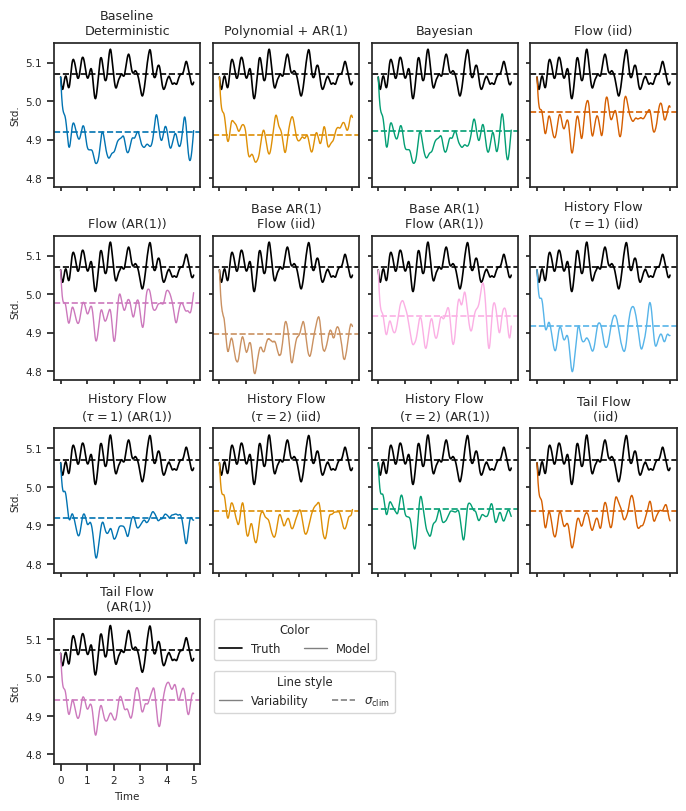

In [19]:
set_model_order(REDUCED_MODEL_ORDER)

t_stop = 5
plot_std = True
k = None
fig = plot_variances_iv_over_time_grid(
    df_metrics_fp,
    figsize=(TEXT_WIDTH, 8),
    t_stop=t_stop,
    plot_std=plot_std,
    ncols=4,
    k=k,
    models_to_plot=REDUCED_MODEL_ORDER,
    bbox_to_anchor=(0.3, 0.24),
    bbox_to_anchor2=(0.3, 0.175),
    legend_cols=2,
    which_base_width="text",
    title_line_breaks=True,
)
plt.show()
std_str = "_std" if plot_std else ""
k_str = "avg_k" if k is None else k
fig.savefig(
    paper_f_dir_p / f"variances_iv_over_time_grid{t_stop}{std_str}_k_{k_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

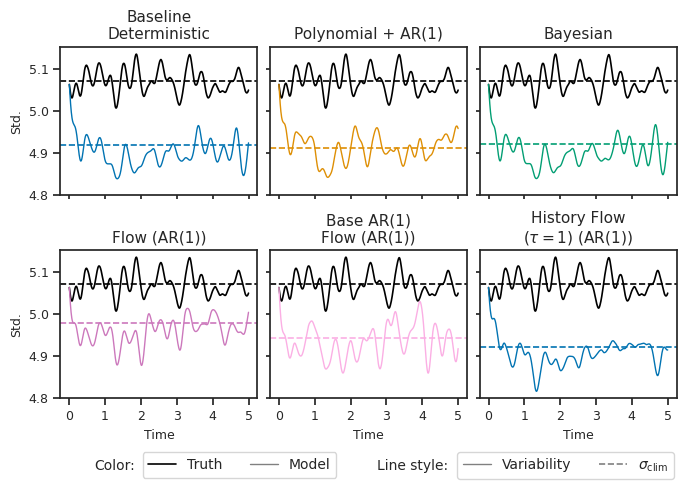

In [20]:
set_model_order(REDUCED_MODEL_ORDER_SELECTED)

t_stop = 5
plot_std = True
k = None
fig = plot_variances_iv_over_time_grid(
    df_metrics_fp,
    figsize=(TEXT_WIDTH, 4.4),
    t_stop=t_stop,
    plot_std=plot_std,
    ncols=3,
    k=k,
    models_to_plot=REDUCED_MODEL_ORDER_SELECTED,
    bbox_to_anchor=(0.5, -0.0),
    bbox_to_anchor2=(1.0, -0.0),
    legend_cols=2,
    legend_loc="upper right",
    which_base_width="column",
    title_line_breaks=True,
    move_legend_title=True,
)
plt.show()
std_str = "_std" if plot_std else ""
k_str = "avg_k" if k is None else k
fig.savefig(
    paper_f_dir_p
    / f"variances_iv_over_time_grid{t_stop}{std_str}_k_{k_str}_selected.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

### Plot spread decomposition (full setting)

In [21]:
def _compute_lead_time_index(lead_time, si):
    """
    Convert lead time to time index.
    For example, with si=0.5, lead_time=1.0 corresponds to time_index=2,
    lead_time=2.0 corresponds to time_index=4, etc.
    """
    return int(lead_time / si)

In [22]:
def plot_spread_components_grid(
    df,
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(14, 10),
    time_values=t,
    t_stop=None,
    plot_std=False,
    show_component_bands=True,
    show_total_band=True,
    ncols=3,
    show_interaction=False,
    k=None,  # select k or mean over k
    show_total_slope=False,  # whether to display slope text
    slope_t0=0.0,  # physical time
    slope_t1=3.0,  # physical time
    slope_symbol="m",  # intuitive/common: y = m x + b
    slope_fmt="{:.3g}",  # formatting for the number
    which_base_width="text",
    title_line_breaks=False,
    bbox_to_anchor=(1.0, 1.02),
    legend_loc="upper right",
    adjust_grid=False,
    first_column_scale=1.25,
    show_line=False,
):
    """
    Grid of panels, one per order_key in MODEL_ORDER.
    Each panel has 2 stacked axes:
      - top: spread_all_avg_i ± spread_all_std_i
      - bottom: components (ens/model + optional interaction), each ± std

    If metrics are [T, K]:
      - k=None -> mean over K
      - k=int  -> select that K index

    NEW: optionally annotate the slope of the TOTAL spread between physical times
         t = slope_t0 and t = slope_t1 in the upper-left of each panel.
    """

    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )
    lw = 1.2
    g = df.copy()
    if g.empty:
        raise ValueError("No data provided")

    first = next(v for v in g["spread_all_avg_i"] if v is not None)
    T = len(_sel_tk(first, k=k))

    if time_values is None:
        x_full = np.arange(T)
        x_label = "Time index"
    else:
        x_full = np.asarray(time_values)
        if len(x_full) != T:
            raise ValueError("time_values length mismatch")
        x_label = "Time"

    mask = np.ones(T, dtype=bool) if t_stop is None else (x_full <= t_stop)
    x = x_full[mask]

    def _transform(avg, std):
        avg = np.asarray(avg)
        std = np.asarray(std)
        if not plot_std:
            return avg, avg - std, avg + std
        y = np.sqrt(np.maximum(avg, 0.0))
        std_y = std / (2.0 * np.maximum(y, 1e-12))
        return y, y - std_y, y + std_y

    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)
    if not keys:
        raise ValueError("No matching models_to_plot found in MODEL_ORDER")

    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    if adjust_grid:
        # give extra width to first column (y labels) and extra height to last row (x labels)
        width_ratios = [first_column_scale] + [1.0] * (ncols - 1)
        height_ratios = [1.0] * (nrows - 1) + [1.20]

        outer = fig.add_gridspec(
            nrows,
            ncols,
            wspace=0.1,
            hspace=0.6,
            width_ratios=width_ratios,
            height_ratios=height_ratios,
        )
    else:
        outer = fig.add_gridspec(nrows, ncols, wspace=0.1, hspace=0.6)

    ax_top0 = None
    ax_bot0 = None

    comps = [
        ("spread_ens_avg_i", "spread_ens_std_i", "--", "Ens"),
        ("spread_models_avg_i", "spread_models_std_i", ":", "Model"),
    ]
    if show_interaction:
        comps.append(("interaction_avg_i", "interaction_std_i", "-.", "Interact"))

    for idx, order_key in enumerate(keys):
        r, c = divmod(idx, ncols)
        sub = outer[r, c].subgridspec(2, 1, height_ratios=[0.5, 0.5], hspace=0.01)

        ax1 = fig.add_subplot(sub[0, 0], sharex=ax_top0, sharey=ax_top0)
        ax2 = fig.add_subplot(sub[1, 0], sharex=ax_bot0, sharey=ax_bot0)
        if ax_top0 is None:
            ax_top0, ax_bot0 = ax1, ax2

        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        color = COLOR_MAP.get(order_key, None)

        # ---- TOTAL (top) ----
        y_total_full = None  # NEW: keep full y (unmasked) for slope
        try:
            avg_full = select_metric_from_df(
                g, "spread_all_avg_i", model, noise, ar_order, delta_t
            )
            std_full = select_metric_from_df(
                g, "spread_all_std_i", model, noise, ar_order, delta_t
            )

            avg_full_sel = _sel_tk(avg_full, k=k)
            std_full_sel = _sel_tk(std_full, k=k)

            y_full, ylo_full, yhi_full = _transform(avg_full_sel, std_full_sel)
            y_total_full = np.asarray(y_full)

            # plot masked window
            avg = np.asarray(avg_full_sel)[mask]
            std = np.asarray(std_full_sel)[mask]
            y, ylo, yhi = _transform(avg, std)

            ax1.plot(x, y, color=color, linewidth=lw)
            if show_total_band:
                ax1.fill_between(x, ylo, yhi, color=color, alpha=0.2)

        except Exception:
            pass

        # ---- slope annotation in upper-left of each panel (on the top axis) ----
        if show_total_slope and (y_total_full is not None):
            si = select_metric_from_df(g, "si", model, noise, ar_order, delta_t)
            if si is not None and si > 0:
                i0 = _compute_lead_time_index(slope_t0, si)
                i1 = _compute_lead_time_index(slope_t1, si)
                if (
                    0 <= i0 < len(y_total_full)
                    and 0 <= i1 < len(y_total_full)
                    and i1 != i0
                ):
                    # slope of the plotted quantity y over physical time
                    m_val = (y_total_full[i1] - y_total_full[i0]) / (
                        slope_t1 - slope_t0
                    )

                    ax1.text(
                        0.02,
                        0.95,
                        rf"${slope_symbol}={slope_fmt.format(m_val)}$",
                        transform=ax1.transAxes,
                        color="black",
                        va="top",
                        ha="left",
                        fontsize=scaled_fontsize(9, figsize[0], which_base_width),
                        bbox=dict(
                            boxstyle="round,pad=0.2",
                            facecolor="white",
                            alpha=0.7,
                            linewidth=0.0,
                        ),
                    )
                    # optional guide line: only in first panel
                    if show_line and idx == 0:
                        x_line = np.array([slope_t0, slope_t1])
                        y_line = np.array([y_total_full[i0], y_total_full[i1]])
                        ax1.plot(
                            x_line,
                            y_line,
                            color="black",
                            linewidth=1.6,
                            linestyle="-",
                            zorder=5,
                        )

        # ---- COMPONENTS (bottom) ----
        for avg_key, std_key, ls, comp_name in comps:
            try:
                avg_full = select_metric_from_df(
                    g, avg_key, model, noise, ar_order, delta_t
                )
                std_full = select_metric_from_df(
                    g, std_key, model, noise, ar_order, delta_t
                )

                avg = _sel_tk(avg_full, k=k)[mask]
                std = _sel_tk(std_full, k=k)[mask]

                y, ylo, yhi = _transform(avg, std)

                ax2.plot(x, y, color=color, linestyle=ls, linewidth=lw, label=comp_name)
                if show_component_bands:
                    ax2.fill_between(x, ylo, yhi, color=color, alpha=0.20)
            except Exception:
                continue

        title = parse_label(
            model, noise, ar_order, delta_t, line_breaks=title_line_breaks
        )
        if adjust_grid and "\n" not in title:
            # this is bit hacky but we want all titles to be two lines for equal spacing
            title = "\n" + title
        ax1.set_title(title)
        ax1.tick_params(labelbottom=False)

        ylab = "Var." if not plot_std else "Std."
        ax1.set_ylabel(f"Total {ylab}")
        ax2.set_ylabel(f"Component {ylab}")

        ax1.tick_params(axis="both", bottom=False, left=True, length=5)
        ax2.tick_params(axis="x", bottom=True, length=3)
        ax1.tick_params(axis="y", left=True, length=5)
        ax2.tick_params(axis="y", left=True, length=5)

        if r == nrows - 1:
            ax2.set_xlabel(x_label)
            ax2.tick_params(axis="x", bottom=True, length=5)
        else:
            ax2.tick_params(labelbottom=False)

        if c != 0:
            ax1.set_ylabel("")
            ax2.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.tick_params(labelleft=False)
            ax1.tick_params(axis="y", left=True, length=3)
            ax2.tick_params(axis="y", left=True, length=3)

    legend_handles = [
        Line2D([0], [0], color="black", linewidth=lw, label="Total"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=lw, label="Ens"),
        Line2D([0], [0], color="black", linestyle=":", linewidth=lw, label="Model"),
    ]
    if show_total_band:
        legend_handles.insert(
            1, Patch(facecolor="black", alpha=0.2, label="Total ± Std.")
        )

    if show_interaction:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="-.",
                linewidth=lw,
                label="Interaction",
            )
        )

    fig.legend(
        handles=legend_handles,
        loc=legend_loc,
        bbox_to_anchor=bbox_to_anchor,
        ncol=len(legend_handles),
        frameon=True,
    )

    return fig

#### Paper ready plot

In [23]:
paper_f_dir_f = paper_figures_base_dir / "full"
paper_f_dir_f.mkdir(parents=True, exist_ok=True)
print(f"Saving to figures dir: {Path(*paper_f_dir_f.parts[-4:])}")

Saving to figures dir: paper/figures/ensemble_evaluation/full


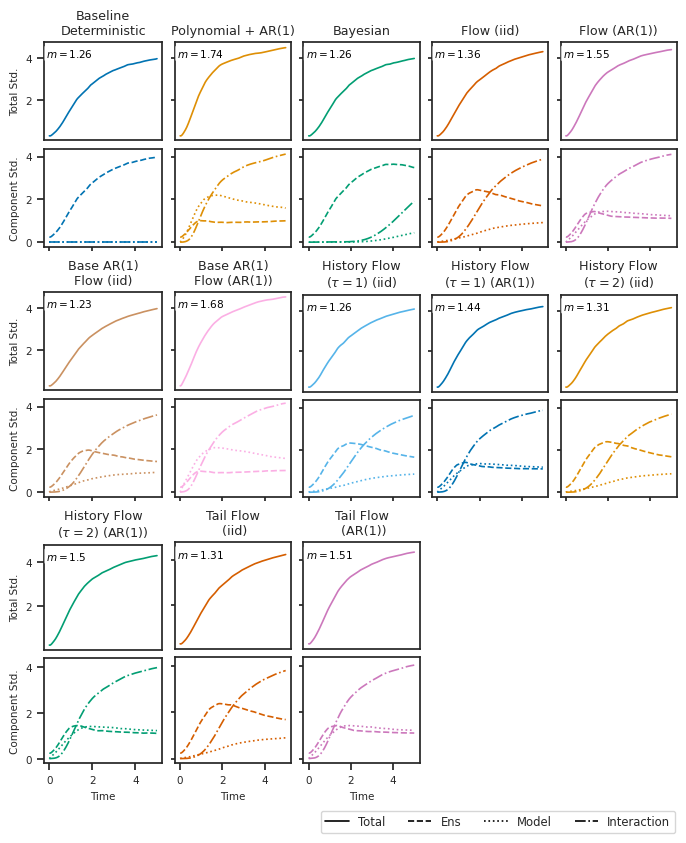

In [24]:
set_model_order(REDUCED_MODEL_ORDER)

t_stop = 5
plot_std = True
show_components_bands = False
show_total_band = False
k = None
show_total_slope = True  # whether to display slope text
slope_t0 = 0  # physical time
slope_t1 = 2  # physical time
slope_symbol = "m"  # intuitive/common: y = m x + b
slope_fmt = "{:.3g}"  # formatting for the number
fig = plot_spread_components_grid(
    df_metrics_fp,
    figsize=(TEXT_WIDTH, 8),
    t_stop=t_stop,
    plot_std=plot_std,
    show_component_bands=show_components_bands,
    show_total_band=show_total_band,
    show_interaction=True,
    k=k,
    show_total_slope=show_total_slope,
    slope_t0=slope_t0,
    slope_t1=slope_t1,
    slope_symbol=slope_symbol,
    slope_fmt=slope_fmt,
    ncols=5,
    models_to_plot=REDUCED_MODEL_ORDER,
    title_line_breaks=True,
    bbox_to_anchor=(1.0, 0),
    adjust_grid=True,
)
plt.show()
std_str = "_std" if plot_std else ""
bands_str = "_cbands" if show_components_bands else ""
total_band_str = "_tband" if show_total_band else ""
k_str = "avg_k" if k is None else k
slope_str = f"_slope_{slope_t0}-{slope_t1}" if show_total_slope else ""
fig.savefig(
    paper_f_dir_f
    / f"spread_components_grid_{t_stop}{std_str}{bands_str}{total_band_str}_k_{k_str}{slope_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

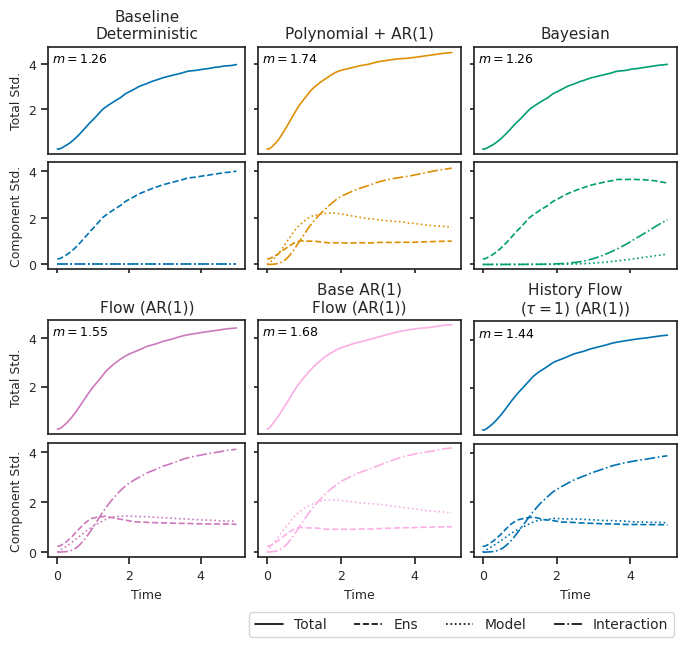

In [29]:
set_model_order(REDUCED_MODEL_ORDER_SELECTED)

t_stop = 5
plot_std = True
show_components_bands = False
show_total_band = False
k = None
show_total_slope = True  # whether to display slope text
slope_t0 = 0  # physical time
slope_t1 = 2  # physical time
slope_symbol = "m"  # intuitive/common: y = m x + b
slope_fmt = "{:.3g}"  # formatting for the number
fig = plot_spread_components_grid(
    df_metrics_fp,
    figsize=(TEXT_WIDTH, 6),
    t_stop=t_stop,
    plot_std=plot_std,
    show_component_bands=show_components_bands,
    show_total_band=show_total_band,
    show_interaction=True,
    k=k,
    show_total_slope=show_total_slope,
    slope_t0=slope_t0,
    slope_t1=slope_t1,
    slope_symbol=slope_symbol,
    slope_fmt=slope_fmt,
    ncols=3,
    models_to_plot=REDUCED_MODEL_ORDER_SELECTED,
    title_line_breaks=True,
    bbox_to_anchor=(1.0, 0.0),
    which_base_width="column",
    adjust_grid=True,
    first_column_scale=1.13,
)
plt.show()
std_str = "_std" if plot_std else ""
bands_str = "_cbands" if show_components_bands else ""
total_band_str = "_tband" if show_total_band else ""
k_str = "avg_k" if k is None else k
slope_str = f"_slope_{slope_t0}-{slope_t1}" if show_total_slope else ""
fig.savefig(
    paper_f_dir_f
    / f"spread_components_grid_{t_stop}{std_str}{bands_str}{total_band_str}_k_{k_str}{slope_str}_selected.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

#### Check component sum

In [32]:
for m in df_metrics_fp["model"].unique():
    sub = df_metrics_fp[df_metrics_fp["model"] == m]

    for idx, row in sub.iterrows():
        a = np.asarray(row["spread_all_avg_i"])
        b = np.asarray(row["sum_components_avg_i"])

        assert np.allclose(a, b), f"Mismatch for model={m}, index={idx}"

        b = np.asarray(row["spread_ens_avg_i"])
        c = np.asarray(row["spread_models_avg_i"])
        d = np.asarray(row["interaction_avg_i"])

        assert np.allclose(a, b + c + d), (
            f"Component sum mismatch for model={m}, index={idx}"
        )

### Compare full vs mix spreads

In [33]:
def plot_spread_total_compare_grid(
    df_metrics_fp,
    df_metrics_m,
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(15, 10),
    time_values=t,
    t_stop=None,
    plot_std=False,
    show_bands=True,
    ncols=3,
    show_total_spread=True,
    k=None,
    which_base_width="text",
    title_line_breaks=False,
    bbox_to_anchor=(1.0, 0.99),
    legend_cols=1,
    legend_loc="upper left",
):
    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )
    lw = 1.2

    gfp = df_metrics_fp.copy()
    gm = df_metrics_m.copy()
    if gfp.empty or gm.empty:
        raise ValueError("One of the input DataFrames is empty")

    # infer T
    first = next(v for v in gfp["spread_all_avg_i"] if v is not None)
    first = np.asarray(first)
    T = first.shape[0]

    # x-axis
    if time_values is None:
        x_full = np.arange(T)
        x_label = "Time index"
    else:
        x_full = np.asarray(time_values)
        x_label = "Time"

    mask = np.ones(T, dtype=bool) if t_stop is None else (x_full <= t_stop)
    x = x_full[mask]

    def _transform(avg, std=None):
        avg = np.asarray(avg)
        if not plot_std:
            if std is None:
                return avg
            std = np.asarray(std)
            return avg, avg - std, avg + std

        y = np.sqrt(np.maximum(avg, 0.0))
        if std is None:
            return y
        std = np.asarray(std)
        std_y = std / (2.0 * np.maximum(y, 1e-12))
        return y, y - std_y, y + std_y

    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    for idx, order_key in enumerate(keys):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        color = COLOR_MAP.get(order_key, None)
        title = parse_label(
            model, noise, ar_order, delta_t, line_breaks=title_line_breaks
        )

        try:
            fp_avg_full = select_metric_from_df(
                gfp, "spread_all_avg_i", model, noise, ar_order, delta_t
            )
            fp_std_full = select_metric_from_df(
                gfp, "spread_all_std_i", model, noise, ar_order, delta_t
            )
            m_avg_full = select_metric_from_df(
                gm, "spread_all_avg_i", model, noise, ar_order, delta_t
            )
            m_std_full = select_metric_from_df(
                gm, "spread_all_std_i", model, noise, ar_order, delta_t
            )

            # ---- ONLY CHANGE: apply k selection ----
            fp_avg = _sel_tk(fp_avg_full, k)
            fp_std = _sel_tk(fp_std_full, k)
            m_avg = _sel_tk(m_avg_full, k)
            m_std = _sel_tk(m_std_full, k)

            if all(len(v) == T for v in (fp_avg, fp_std, m_avg, m_std)):
                y_fp, fp_lo, fp_hi = _transform(fp_avg[mask], fp_std[mask])
                y_m, m_lo, m_hi = _transform(m_avg[mask], m_std[mask])

                ax.plot(
                    x,
                    y_fp,
                    color=color,
                    lw=lw,
                    ls="-",
                    label="Initial-state avg. spread",
                )
                ax.plot(
                    x,
                    y_m,
                    color=color,
                    lw=lw,
                    ls=":",
                    label="Initial-state avg. spread",
                )

                if show_bands:
                    poly = ax.fill_between(
                        x, fp_lo, fp_hi, color=color, alpha=0.30, linewidth=0
                    )
                    poly.set_hatch("///")
                    poly.set_edgecolor(color)
                    poly.set_linewidth(0.0)

                    ax.fill_between(x, m_lo, m_hi, color=color, alpha=0.20, linewidth=0)

        except Exception:
            pass

        if show_total_spread:
            try:
                fp_total_full = select_metric_from_df(
                    gfp, "spread_total", model, noise, ar_order, delta_t
                )
                m_total_full = select_metric_from_df(
                    gm, "spread_total", model, noise, ar_order, delta_t
                )

                fp_total = _sel_tk(fp_total_full, k)
                m_total = _sel_tk(m_total_full, k)

                if len(fp_total) == T and len(m_total) == T:
                    y_fp_tot = _transform(fp_total[mask])
                    y_m_tot = _transform(m_total[mask])

                    ax.plot(
                        x,
                        y_fp_tot,
                        color=color,
                        lw=lw,
                        ls="--",
                        label="Total spread",
                    )
                    ax.plot(
                        x,
                        y_m_tot,
                        color=color,
                        lw=lw,
                        ls=(0, (3, 1, 1, 1)),
                        label="Total spread",
                    )
            except Exception:
                pass

        ax.set_title(title)
        ax.tick_params(axis="both", bottom=True, left=True, length=3)

        if r == nrows - 1:
            ax.set_xlabel(x_label)
            ax.tick_params(axis="x", bottom=True, length=5)
        if c == 0:
            ax.set_ylabel("Variance" if not plot_std else "Std.")
            ax.tick_params(axis="y", left=True, length=5)

    for j in range(n, nrows * ncols):
        rr, cc = divmod(j, ncols)
        axes[rr, cc].axis("off")

    style_handles = [
        # lines: initial-state avg spread
        Line2D(
            [0],
            [0],
            color="black",
            lw=lw,
            ls="-",
            label="Initital state avg. spread (separated setting)",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            lw=lw,
            ls=":",
            label="Initital state avg. spread (mixed setting)",
        ),
    ]

    if show_total_spread:
        style_handles += [
            # lines: total spread
            Line2D(
                [0],
                [0],
                color="black",
                lw=lw,
                ls="--",
                label="Total spread (separated setting)",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                lw=lw,
                ls=(0, (3, 1, 1, 1)),
                label="Total spread (mixed setting)",
            ),
        ]

    if show_bands:
        style_handles += [
            Patch(
                facecolor="black",
                edgecolor="black",
                alpha=0.30,
                hatch="///",
                label=r"Mean ± std band (separated setting)",
            ),
            Patch(
                facecolor="black",
                edgecolor="black",
                alpha=0.20,
                label=r"Mean ± std band (mixed setting)",
            ),
        ]

    fig.legend(
        handles=style_handles,
        loc=legend_loc,
        bbox_to_anchor=bbox_to_anchor,
        frameon=True,
        ncols=legend_cols,
    )

    return fig


#### Paper read plot

In [34]:
paper_f_dir_fm = paper_figures_base_dir / "full_mix"
paper_f_dir_fm.mkdir(parents=True, exist_ok=True)
print(f"Saving to figures dir: {Path(*paper_f_dir_fm.parts[-4:])}")

Saving to figures dir: paper/figures/ensemble_evaluation/full_mix


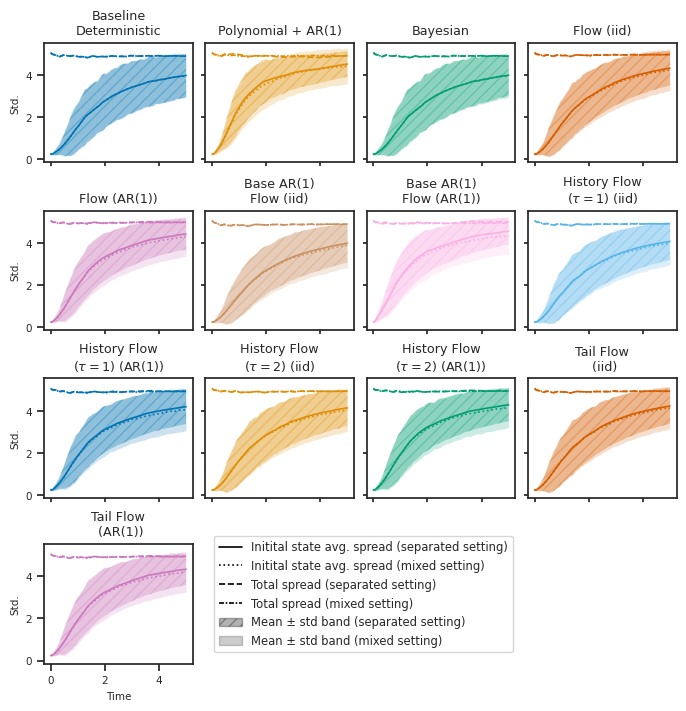

In [35]:
set_model_order(REDUCED_MODEL_ORDER)
t_stop = 5
plot_std = True
show_bands = True
show_total_spread = True
k = None
fig = plot_spread_total_compare_grid(
    df_metrics_fp,
    df_metrics_m,
    figsize=(TEXT_WIDTH, 7),
    t_stop=t_stop,
    plot_std=plot_std,
    show_bands=show_bands,
    models_to_plot=REDUCED_MODEL_ORDER,
    ncols=4,
    show_total_spread=show_total_spread,
    k=k,
    bbox_to_anchor=(0.3, 0.25),
    legend_cols=1,
    title_line_breaks=True,
)
plt.show()
std_str = "_std" if plot_std else ""
bands_str = "_bands" if show_bands else ""
show_total_spread_str = "_with_total" if show_total_spread else "_only_avg_i"
k_str = "avg_k" if k is None else k
# hatches are not saved in PDF (matplotlib issue), so we save both PNG and PDF
fig.savefig(
    paper_f_dir_fm
    / f"spread_total_compare_grid_{t_stop}{std_str}{bands_str}{show_total_spread_str}_k_{k_str}.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=400,
    format="png",
)
fig.savefig(
    paper_f_dir_fm
    / f"spread_total_compare_grid_{t_stop}{std_str}{bands_str}{show_total_spread_str}_k_{k_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

### RMSE with anomaly correlation

In [36]:
def plot_rmse_and_ancr_over_time(
    df_metrics_fp,
    df_metrics_m,
    which="full",  # "full" | "mix"
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(13, 5),
    time_values=t,
    t_stop=None,
    ylim=(-0.05, 1.05),
    which_base_width="text",
    bbox_to_anchor=(1.01, 0.5),
    legend_cols=1,
    columns_or_rows="columns",
    inset_axis=False,
    line_styles=False,
    inset_range=0,  # 0 for main text, 1 for full appendix, 2 for mix appendix
):
    """
    Two-panel comparison plot:
      - Left:  RMSE(t)
      - Right: ANCR/ACC(t)

    Parameters
    ----------
    which : {"full","mix"}
        - "full": plot from df_metrics_fp (solid)
        - "mix":  plot from df_metrics_m  (dashed)
    models_to_plot : list or None
        Filter by order_key or model name.
    """

    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )
    lw = 1.2

    # ---- special line styles for selected models
    # this is a bit of a hack, but basically we decide by configuration
    # which tail flow to show with special linestyle
    which_tail_flow = (
        "ensemble_gcm_tail_flow-white"
        if inset_range == 2  # mix
        else "ensemble_gcm_tail_flow-ar_p-1"  # full
    )
    LINE_STYLE = {
        "ensemble_gcm_baseline_ar_p-1": "dashed",
        which_tail_flow: "dashdot",
        "ensemble_gcm_ar_base_flow-ar_p-1": (0, (1, 1)),  # densely dotted
    }
    if line_styles:
        ls = {ok: LINE_STYLE.get(ok, "solid") for ok in MODEL_ORDER}
    else:
        ls = {ok: "solid" for ok in MODEL_ORDER}

    if which not in ("full", "mix"):
        raise ValueError("which must be one of {'full','mix'}")
    # ----

    # choose source df + linestyle
    if which == "full":
        g = df_metrics_fp.copy()
    else:
        g = df_metrics_m.copy()

    # sanity checks
    for col in ("rmse_t", "ancr_t"):
        if col not in g.columns:
            raise KeyError(
                f"Selected df must contain '{col}'. Available: {list(g.columns)}"
            )

    # infer T (prefer rmse_t, fallback to ancr_t)
    first_rmse = next(
        (np.asarray(v) for v in g["rmse_t"].to_list() if v is not None), None
    )
    if first_rmse is not None:
        T = int(np.asarray(first_rmse).shape[0])
    else:
        first_acc = next(
            (np.asarray(v) for v in g["ancr_t"].to_list() if v is not None), None
        )
        if first_acc is None:
            raise ValueError("Selected df contains no arrays in 'rmse_t' or 'ancr_t'.")
        T = int(np.asarray(first_acc).shape[0])

    # x-axis
    if time_values is None:
        x_full = np.arange(T)
        x_label = "Time index"
    else:
        x_full = np.asarray(time_values)
        if x_full.shape[0] != T:
            raise ValueError(f"time_values length {x_full.shape[0]} != T {T}")
        x_label = "Time"

    mask = np.ones(T, dtype=bool) if t_stop is None else (x_full <= t_stop)
    if not np.any(mask):
        raise ValueError(f"t_stop={t_stop} is smaller than the smallest time value.")
    x = x_full[mask]

    # choose models (order_keys)
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)
    if not keys:
        raise ValueError("No matching models_to_plot found in MODEL_ORDER")

    # figure
    (nrows, ncols) = (1, 2) if columns_or_rows == "columns" else (2, 1)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False,
    )
    if columns_or_rows == "columns":
        ax_rmse = axes[0, 0]
        ax_ancr = axes[0, 1]
    else:  # rows
        ax_rmse = axes[0, 0]
        ax_ancr = axes[1, 0]

    ax_rmse.set_title("RMSE")
    ax_ancr.set_title("Anomaly correlation")

    # baselines
    ax_rmse.axhline(0.0, linestyle="--", linewidth=1.0, color="0.6")
    ax_ancr.axhline(0.0, linestyle="--", linewidth=1.0, color="0.6")

    # plot lines
    for order_key in keys:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)

        # RMSE
        try:
            y_rmse = select_metric_from_df(g, "rmse_t", model, noise, ar_order, delta_t)
            if len(y_rmse) == T:
                ax_rmse.plot(
                    x,
                    np.asarray(y_rmse)[mask],
                    linewidth=lw,
                    color=COLOR_MAP.get(order_key, None),
                    linestyle=ls.get(order_key, "solid"),
                )
        except (KeyError, ValueError, RuntimeError):
            pass

        # ANCR
        try:
            y_ancr = select_metric_from_df(g, "ancr_t", model, noise, ar_order, delta_t)
            if len(y_ancr) == T:
                ax_ancr.plot(
                    x,
                    np.asarray(y_ancr)[mask],
                    linewidth=lw,
                    color=COLOR_MAP.get(order_key, None),
                    linestyle=ls.get(order_key, "solid"),
                )
        except (KeyError, ValueError, RuntimeError):
            pass

    # labels / limits
    ax_rmse.set_xlabel(x_label)
    ax_ancr.set_xlabel(x_label)

    ax_rmse.set_ylabel("RMSE")
    ax_ancr.set_ylabel("Anomaly correlation")
    ax_ancr.set_ylim(*ylim)

    for ax in (ax_rmse, ax_ancr):
        ax.margins(x=0.02)
        ax.tick_params(bottom=True, left=True)

    # inset axis
    if inset_axis:
        if inset_range == 0:  # main text (full)
            x1, x2, y1, y2 = 4, 5, 4.64, 4.84  # subregion of the original image
        elif inset_range == 1:  # appendix full
            x1, x2, y1, y2 = 4, 5, 4.6, 4.9
        elif inset_range == 2:  # appendix mix
            x1, x2, y1, y2 = 4, 5, 4.69, 4.99
        pos = [0.4, 0.1, 0.5, 0.4]  # position and size
        axins = ax_rmse.inset_axes(
            pos, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[]
        )
        # plot lines
        for order_key in keys:
            model, noise, ar_order, delta_t = model_order_to_query(order_key)

            # RMSE
            try:
                y_rmse = select_metric_from_df(
                    g, "rmse_t", model, noise, ar_order, delta_t
                )
                if len(y_rmse) == T:
                    axins.plot(
                        x,
                        np.asarray(y_rmse)[mask],
                        linewidth=lw,
                        color=COLOR_MAP.get(order_key, None),
                        linestyle=ls.get(order_key, "solid"),
                    )
            except (KeyError, ValueError, RuntimeError):
                pass

        ax_rmse.indicate_inset_zoom(axins, edgecolor="black")

        if inset_range == 0:  # main text (full)
            x1, x2, y1, y2 = 4.2, 5, 0.295, 0.395
            pos = [0.05, 0.07, 0.4, 0.4]  # position and size
        elif inset_range == 1:  # appendix full
            x1, x2, y1, y2 = 4, 5, 0.295, 0.395  # subregion of the original image
            pos = [0.05, 0.06, 0.5, 0.4]  # position and size
        elif inset_range == 2:  # appendix mix
            x1, x2, y1, y2 = 4, 5, 0.29, 0.39  # subregion of the original image
            pos = [0.05, 0.06, 0.5, 0.4]  # position and size

        axins = ax_ancr.inset_axes(
            pos, xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[]
        )
        for order_key in keys:
            model, noise, ar_order, delta_t = model_order_to_query(order_key)

            # ANCR
            try:
                y_ancr = select_metric_from_df(
                    g, "ancr_t", model, noise, ar_order, delta_t
                )
                if len(y_ancr) == T:
                    axins.plot(
                        x,
                        np.asarray(y_ancr)[mask],
                        linewidth=lw,
                        color=COLOR_MAP.get(order_key, None),
                        linestyle=ls.get(order_key, "solid"),
                    )
            except (KeyError, ValueError, RuntimeError):
                pass
        ax_ancr.indicate_inset_zoom(axins, edgecolor="black")

    # one legend: model colors only (no linestyle meaning needed)
    model_handles = [
        Line2D(
            [0],
            [0],
            color=COLOR_MAP.get(ok, None),
            lw=lw,
            label=parse_label(*model_order_to_query(ok), line_breaks=False),
            linestyle=ls.get(ok, "solid"),  # unified legend style for models
        )
        for ok in keys
    ]

    fig.legend(
        handles=model_handles,
        bbox_to_anchor=bbox_to_anchor,
        frameon=True,
        ncols=legend_cols,
    )

    fig.tight_layout()

    return fig

#### Paper ready plot

In [37]:
paper_f_dir_f = paper_figures_base_dir / "full"
paper_f_dir_f.mkdir(parents=True, exist_ok=True)
print(f"Saving full to figures dir: {Path(*paper_f_dir_f.parts[-4:])}")

paper_f_dir_m = paper_figures_base_dir / "mix"
paper_f_dir_m.mkdir(parents=True, exist_ok=True)
print(f"Saving mix to figures dir: {Path(*paper_f_dir_m.parts[-4:])}")

Saving full to figures dir: paper/figures/ensemble_evaluation/full
Saving mix to figures dir: paper/figures/ensemble_evaluation/mix


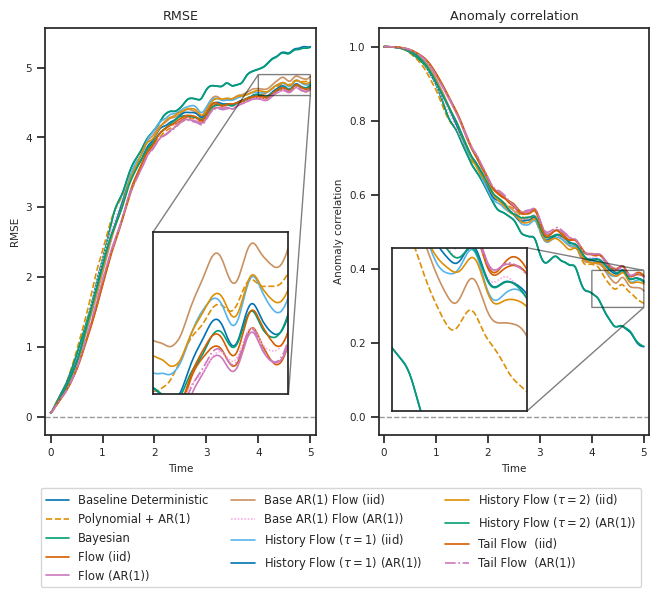

In [38]:
set_model_order(REDUCED_MODEL_ORDER)

t_stop = 5
which = "full"  # full or mix
inset_range = 1 if which == "full" else 2
pf_dir = paper_f_dir_f if which == "full" else paper_f_dir_m

fig = plot_rmse_and_ancr_over_time(
    df_metrics_fp,
    df_metrics_m,
    which=which,
    figsize=(TEXT_WIDTH, 5),
    t_stop=t_stop,
    bbox_to_anchor=(0.97, 0.02),
    legend_cols=3,
    models_to_plot=REDUCED_MODEL_ORDER,
    inset_axis=True,
    line_styles=True,
    inset_range=inset_range,
)
plt.show()
which_str = "_full" if which == "full" else "_mix"

fig.savefig(
    pf_dir / f"rmse_ancr_time_{t_stop}{which_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
# reset model
set_model_order(MODEL_ORDER_DEFAULT)

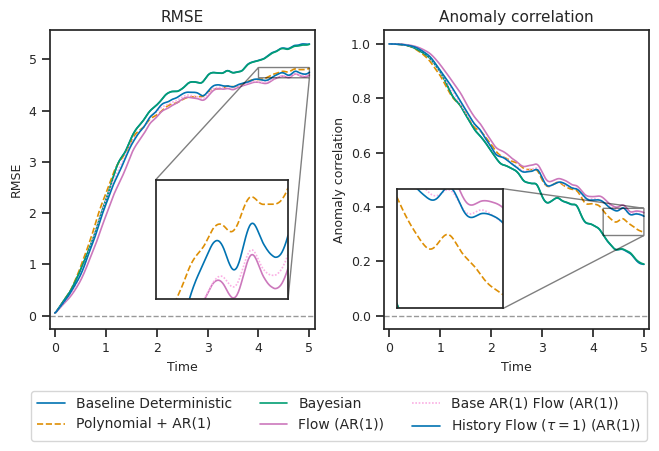

In [39]:
set_model_order(REDUCED_MODEL_ORDER_SELECTED)

t_stop = 5
which = "full"  # full or mix
pf_dir = paper_f_dir_f if which == "full" else paper_f_dir_m

fig = plot_rmse_and_ancr_over_time(
    df_metrics_fp,
    df_metrics_m,
    which=which,
    figsize=(TEXT_WIDTH, 4),
    t_stop=t_stop,
    bbox_to_anchor=(0.98, 0.02),
    models_to_plot=REDUCED_MODEL_ORDER_SELECTED,
    which_base_width="column",
    legend_cols=3,
    line_styles=True,
    inset_axis=True,
    inset_range=0,
)
plt.show()
which_str = "_full" if which == "full" else "_mix"
fig.savefig(
    pf_dir / f"rmse_ancr_time_{t_stop}{which_str}_selected.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

#### Values at t=5

In [40]:
def _compute_lead_time_index(lead_time, si):
    """
    Convert lead time to time index.
    For example, with si=0.5, lead_time=1.0 corresponds to time_index=2,
    lead_time=2.0 corresponds to time_index=4, etc.
    """
    return int(lead_time / si)

In [41]:
def print_rmse_and_ancr(
    df_metrics_fp: pd.DataFrame,
    df_metrics_m: pd.DataFrame,
    lead_time=5,
    models_to_print=None,  # list of order_keys or model names; None = all models in df
    MODEL_ORDER=MODEL_ORDER,  # optional: if you want stable ordering via MODEL_ORDER
    digits=4,
    k=None,
):
    """
    Prints climatological (time-marginal) summaries for:
      - Truth (from df_metrics_fp): mean_true, x_min_true/x_max_true, median_true, q25_true/q75_true (or iqr_true)
      - Full model (from df_metrics_fp): mean, x_min/x_max, median, q25/q75 (or iqr)
      - Mix model (from df_metrics_m): mean, x_min/x_max, median, q25/q75 (or iqr)

    Each quantity in the dfs is a 1D array over time [T]. We marginalize by taking the time-mean:
      mean_clim   = mean_t.mean()
      range_clim  = mean_t( x_max_t - x_min_t )   (uses x_min/x_max; equals mean(data_range) if consistent)
      median_clim = median_t.mean()
      iqr_clim    = mean_t( q75_t - q25_t )       (uses q25/q75; equals mean(iqr) if consistent)
    """

    g_full = df_metrics_fp.copy()
    g_mix = df_metrics_m.copy()

    # sanity checks
    for col in ("rmse_t", "ancr_t"):
        if col not in g_full.columns:
            raise KeyError(
                f"Selected df must contain '{col}'. Available: {list(g_full.columns)}"
            )
        if col not in g_mix.columns:
            raise KeyError(
                f"Selected df must contain '{col}'. Available: {list(g_mix.columns)}"
            )

    time_idx = _compute_lead_time_index(
        lead_time, g_full["si"].iloc[0]
    )  # assuming si is the same for all rows

    if time_idx >= g_full["rmse_t"].iloc[0].shape[0]:
        raise ValueError(
            f"Lead time index {time_idx} out of bounds for rmse_t with shape {g_full['rmse_t'].iloc[0].shape}"
        )
    if time_idx >= g_mix["rmse_t"].iloc[0].shape[0]:
        raise ValueError(
            f"Lead time index {time_idx} out of bounds for rmse_t with shape {g_mix['rmse_t'].iloc[0].shape}"
        )
    if time_idx >= g_full["ancr_t"].iloc[0].shape[0]:
        raise ValueError(
            f"Lead time index {time_idx} out of bounds for ancr_t with shape {g_full['ancr_t'].iloc[0].shape}"
        )
    if time_idx >= g_mix["ancr_t"].iloc[0].shape[0]:
        raise ValueError(
            f"Lead time index {time_idx} out of bounds for ancr_t with shape {g_mix['ancr_t'].iloc[0].shape}"
        )

    # choose models (order_keys)
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_print is None
            or order_key in models_to_print
            or model in models_to_print
        ):
            keys.append(order_key)
    if not keys:
        raise ValueError("No matching models_to_print found in MODEL_ORDER")

    def _fmt(v):
        return f"{v:.{digits}f}"

    # plot lines
    for order_key in keys:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        rmse_full = select_metric_from_df(
            g_full, "rmse_t", model, noise, ar_order, delta_t
        )
        ancr_full = select_metric_from_df(
            g_full, "ancr_t", model, noise, ar_order, delta_t
        )
        rmse_mix = select_metric_from_df(
            g_mix, "rmse_t", model, noise, ar_order, delta_t
        )
        ancr_mix = select_metric_from_df(
            g_mix, "ancr_t", model, noise, ar_order, delta_t
        )
        print(f"Model: {order_key}")
        print(
            f"  RMSE at lead_time={lead_time} (time index {time_idx}): Full={_fmt(rmse_full[time_idx])}, Mix={_fmt(rmse_mix[time_idx])}"
        )
        print(
            f"  ANCR at lead_time={lead_time} (time index {time_idx}): Full={_fmt(ancr_full[time_idx])}, Mix={_fmt(ancr_mix[time_idx])}"
        )
        print("")


In [42]:
print_rmse_and_ancr(df_metrics_fp, df_metrics_m, lead_time=5)

Model: ensemble_gcm_baseline_det
  RMSE at lead_time=5 (time index 1000): Full=5.2997, Mix=5.2997
  ANCR at lead_time=5 (time index 1000): Full=0.1888, Mix=0.1888

Model: ensemble_gcm_baseline_ar_p-1
  RMSE at lead_time=5 (time index 1000): Full=4.8266, Mix=4.8858
  ANCR at lead_time=5 (time index 1000): Full=0.3062, Mix=0.2818

Model: ensemble_gcm_bayes
  RMSE at lead_time=5 (time index 1000): Full=5.2927, Mix=5.3109
  ANCR at lead_time=5 (time index 1000): Full=0.1898, Mix=0.1862

Model: ensemble_gcm_flow-white
  RMSE at lead_time=5 (time index 1000): Full=4.6931, Mix=4.7823
  ANCR at lead_time=5 (time index 1000): Full=0.3812, Mix=0.3625

Model: ensemble_gcm_flow-ar_p-1
  RMSE at lead_time=5 (time index 1000): Full=4.6921, Mix=4.7725
  ANCR at lead_time=5 (time index 1000): Full=0.3788, Mix=0.3600

Model: ensemble_gcm_ar_base_flow-white
  RMSE at lead_time=5 (time index 1000): Full=4.8720, Mix=4.9513
  ANCR at lead_time=5 (time index 1000): Full=0.3400, Mix=0.3328

Model: ensemble_g

### Data range

In [43]:
def print_climatology_summary(
    df_metrics_fp: pd.DataFrame,
    df_metrics_m: pd.DataFrame,
    models_to_print=None,  # list of order_keys or model names; None = all models in df
    MODEL_ORDER=None,  # optional: if you want stable ordering via MODEL_ORDER
    digits=4,
    k=None,
):
    """
    Prints climatological (time-marginal) summaries for:
      - Truth (from df_metrics_fp): mean_true, x_min_true/x_max_true, median_true, q25_true/q75_true (or iqr_true)
      - Full model (from df_metrics_fp): mean, x_min/x_max, median, q25/q75 (or iqr)
      - Mix model (from df_metrics_m): mean, x_min/x_max, median, q25/q75 (or iqr)

    Each quantity in the dfs is a 1D array over time [T]. We marginalize by taking the time-mean:
      mean_clim   = mean_t.mean()
      range_clim  = mean_t( x_max_t - x_min_t )   (uses x_min/x_max; equals mean(data_range) if consistent)
      median_clim = median_t.mean()
      iqr_clim    = mean_t( q75_t - q25_t )       (uses q25/q75; equals mean(iqr) if consistent)
    """

    def _arr(x):
        return np.asarray(x, dtype=float)

    def _sel_k_and_time_mean(x):
        x = _arr(x)
        x = _sel_tk(x, k)
        return float(np.nanmean(x))

    def _summ_from_row(row, suffix=""):
        # suffix="" for model, suffix="_true" for truth variables stored as mean_true, x_min_true, ...
        mean = _sel_k_and_time_mean(row[f"mean{suffix}"])
        xmin = _sel_k_and_time_mean(row[f"x_min{suffix}"])
        xmax = _sel_k_and_time_mean(row[f"x_max{suffix}"])
        rng = _sel_k_and_time_mean(
            _arr(row[f"x_max{suffix}"]) - _arr(row[f"x_min{suffix}"])
        )
        med = _sel_k_and_time_mean(row[f"median{suffix}"])

        # prefer q25/q75 to define IQR (more robust than averaging precomputed iqr if any mismatch)
        q25 = _sel_k_and_time_mean(row[f"q25{suffix}"])
        q75 = _sel_k_and_time_mean(row[f"q75{suffix}"])
        iqr = _sel_k_and_time_mean(
            _arr(row[f"q75{suffix}"]) - _arr(row[f"q25{suffix}"])
        )

        return {
            "mean": mean,
            "range": rng,
            "median": med,
            "iqr": iqr,
            "xmin": xmin,
            "xmax": xmax,
            "q25": q25,
            "q75": q75,
        }

    def _fmt(v):
        return f"{v:.{digits}f}"

    def _want_model(mname):
        if models_to_print is None:
            return True
        return mname in models_to_print

    # ---- K ----
    k_str = "avg. k" if k is None else f"k={k}"
    print("Summary for " + k_str)
    print("")

    # ---- Truth (single, from fp) ----
    truth_row = df_metrics_fp.iloc[0]
    truth = _summ_from_row(truth_row, suffix="_true")

    print("Truth (from df_metrics_fp)")
    print(f"  mean   : {_fmt(truth['mean'])}")
    print(
        f"  range  : {_fmt(truth['range'])}   (xmin={_fmt(truth['xmin'])}, xmax={_fmt(truth['xmax'])})"
    )
    print(f"  median : {_fmt(truth['median'])}")
    print(
        f"  IQR    : {_fmt(truth['iqr'])}     (q25={_fmt(truth['q25'])}, q75={_fmt(truth['q75'])})"
    )
    print("")

    # ---- Decide model iteration order ----
    if MODEL_ORDER is not None:
        # MODEL_ORDER contains order_keys; we just want model names appearing in the dfs in that order
        ordered_models = []
        for ok in MODEL_ORDER:
            try:
                model_name = ok if isinstance(ok, str) else str(ok)
            except Exception:
                continue
            # if ok is actually an order_key, user likely wants parse elsewhere; fallback to df order
            # so only use MODEL_ORDER if its entries match df['model'] values
            ordered_models.append(model_name)
        # if mismatch, fallback
        df_model_list = list(df_metrics_fp["model"].unique())
        models_fp = [m for m in ordered_models if m in df_model_list] or df_model_list
    else:
        models_fp = list(df_metrics_fp["model"].unique())

    # ---- Full models (from fp) ----
    print("Full model setting (N_init x N_ens x N_model):")
    for m in models_fp:
        if not _want_model(m):
            continue
        rr = df_metrics_fp[df_metrics_fp["model"] == m]
        if rr.empty:
            continue
        s = _summ_from_row(rr.iloc[0], suffix="")
        print(f"Model: {m}")
        print(f"  mean   : {_fmt(s['mean'])}")
        print(
            f"  range  : {_fmt(s['range'])}   (xmin={_fmt(s['xmin'])}, xmax={_fmt(s['xmax'])})"
        )
        print(f"  median : {_fmt(s['median'])}")
        print(
            f"  IQR    : {_fmt(s['iqr'])}     (q25={_fmt(s['q25'])}, q75={_fmt(s['q75'])})"
        )
    print("")

    # ---- Mix models (from m) ----

    models_m = list(df_metrics_m["model"].unique())
    print("Mix model setting (N_init x N_ens with stochastic physics):")
    for m in models_m:
        if not _want_model(m):
            continue
        rr = df_metrics_m[df_metrics_m["model"] == m]
        if rr.empty:
            continue
        s = _summ_from_row(rr.iloc[0], suffix="")
        print(f"Model: {m}")
        print(f"  mean   : {_fmt(s['mean'])}")
        print(
            f"  range  : {_fmt(s['range'])}   (xmin={_fmt(s['xmin'])}, xmax={_fmt(s['xmax'])})"
        )
        print(f"  median : {_fmt(s['median'])}")
        print(
            f"  IQR    : {_fmt(s['iqr'])}     (q25={_fmt(s['q25'])}, q75={_fmt(s['q75'])})"
        )

In [44]:
print_climatology_summary(df_metrics_fp, df_metrics_m, k=None)

Summary for avg. k

Truth (from df_metrics_fp)
  mean   : 3.7849
  range  : 22.7014   (xmin=-7.7784, xmax=14.9229)
  median : 3.5160
  IQR    : 7.5223     (q25=0.0622, q75=7.5845)

Full model setting (N_init x N_ens x N_model):
Model: ensemble_gcm_baseline_det
  mean   : 3.8832
  range  : 23.7416   (xmin=-8.0376, xmax=15.7040)
  median : 3.6425
  IQR    : 7.4090     (q25=0.1745, q75=7.5835)
Model: ensemble_gcm_baseline_ar_p
  mean   : 3.8264
  range  : 26.5002   (xmin=-9.3577, xmax=17.1425)
  median : 3.5916
  IQR    : 7.3508     (q25=0.1606, q75=7.5114)
Model: ensemble_gcm_bayes
  mean   : 3.8824
  range  : 24.3560   (xmin=-8.3641, xmax=15.9919)
  median : 3.6416
  IQR    : 7.4068     (q25=0.1745, q75=7.5813)
Model: ensemble_gcm_flow
  mean   : 3.8942
  range  : 23.5234   (xmin=-7.9610, xmax=15.5624)
  median : 3.4957
  IQR    : 7.7553     (q25=0.0773, q75=7.8326)
Model: ensemble_gcm_ar_base_flow
  mean   : 3.8991
  range  : 22.7378   (xmin=-7.5662, xmax=15.1716)
  median : 3.4935
  I

## Reliability plots

### Spread-error relationship 

In [45]:
def _compute_lead_time_index(lead_time, si):
    """
    Convert lead time to time index.
    For example, with si=0.5, lead_time=1.0 corresponds to time_index=2,
    lead_time=2.0 corresponds to time_index=4, etc.
    """
    return int(lead_time / si)

In [46]:
META_COLS = [
    "model",
    "noise_type",
    "ar_order",
    "delta_t",
    "c",
    "f_schedule",
    "truth_config_key",
]


def make_spread_error_df(df, lead_times, num_samples_per_bin=100):
    """
    build long df with one row per (original row, lt), picking rmse/spread at that lead time
    """
    rows = []

    for _, r in df.iterrows():
        si = r["si"]
        x_diff = np.asarray(r["diff_itk"])  # N_init, T, K
        x_std = np.asarray(r["std_itk"])  # N_init, T, K

        n_init, T, K = x_diff.shape
        n_samples = n_init * K
        n_bins = n_samples // num_samples_per_bin
        print(
            f"Bins: {n_bins} (n_init={n_init}, K={K}, num_samples_per_bin={num_samples_per_bin})"
        )

        for lt in lead_times:
            idx = int(_compute_lead_time_index(lt, si))  # index into time series

            # flatten to combine N_init initial conditions and K dimensions
            x_diff_rt = x_diff[:, idx, :].flatten()
            x_std_rt = x_std[:, idx, :].flatten()

            # sort into order of increasing spread
            sorted_inds = np.argsort(x_std_rt.flatten())
            x_diff_sorted = x_diff_rt[sorted_inds]
            x_std_sorted = x_std_rt[sorted_inds]

            # reshape into bins
            x_diff_bins = x_diff_sorted.reshape((n_bins, num_samples_per_bin))
            x_std_bins = x_std_sorted.reshape((n_bins, num_samples_per_bin))

            # average across variances and take std of err
            # rms spread: the standard deviation of the ensemble for each bin
            spread = x_std_bins.mean(axis=-1)

            ## rms error: the standard deviation of the ensemble mean error for each bin
            sigma_err = np.sqrt((x_diff_bins**2).mean(axis=-1))

            rows.append(
                {
                    **{c: r[c] for c in META_COLS},
                    "lead_time": lt,
                    "rms_error": sigma_err,
                    "rms_spread": spread,
                }
            )

    return pd.DataFrame(rows)


In [47]:
lead_times = [1, 2, 3, 4, 5]
num_samples_per_bin = 100
df_spread_error_f = make_spread_error_df(
    df_metrics_fp, num_samples_per_bin=num_samples_per_bin, lead_times=lead_times
)

Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)


In [48]:
lead_times = [1, 2, 3, 4, 5]
num_samples_per_bin = 100
df_spread_error_m = make_spread_error_df(
    df_metrics_m, num_samples_per_bin=num_samples_per_bin, lead_times=lead_times
)

Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)
Bins: 24 (n_init=300, K=8, num_samples_per_bin=100)


### Plot spread-error relationships

In [49]:
def select_spread_error_from_df(
    df, model, noise_type=None, ar_order=None, delta_t=None
):
    """
    Selects rows matching (model, noise_type, ar_order, delta_t) and returns the sub-DataFrame.

    Conventions:
      - noise_type=None, ar_order missing -> no noise
      - noise_type="white" -> white noise, ar_order treated as 0
      - noise_type="ar_p"  -> AR(p), ar_order must be p
      - baseline_ar_p special-case:
            model contains "baseline_ar_p" and noise_type is None but ar_order is int
            -> treat as baseline AR(p) even though noise_type is missing in DF

    delta_t:
      - If delta_t is None, rows must have delta_t missing (NaN)
      - If delta_t is provided, rows must match exactly
    """
    d = df.copy()
    sub = _select_sub_df(d, model, noise_type, ar_order, delta_t)

    if sub.empty:
        raise KeyError(
            f"No rows found for model={model}, noise_type={noise_type}, "
            f"ar_order={ar_order}, delta_t={delta_t}"
        )

    return sub

In [50]:
def plot_spread_error_all_models(
    df,
    lead_time,
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(11, 5),
    M=400,  # n_ens * n_models for full, n_ens for mix
    which_base_width="text",
    bbox_to_anchor=(1.01, 0.5),
    legend_cols=1,
    legend_loc="upper left",
    subplot_cols=3,
    speical_markers_and_lines=False,
):
    """
    Spread-error diagram.

    If lead_time is an int, plot one panel.
    If lead_time is a list, plot one subplot per lead time.
    """
    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )

    if speical_markers_and_lines:
        # special markers and line styles for selected models
        MARKER_LINE_STYLE_SPECIAL = {
            "ensemble_gcm_baseline_ar_p-1": ("^", "dashed"),
            "ensemble_gcm_flow-ar_p-1": ("s", "dashdot"),
            "ensemble_gcm_ar_base_flow-ar_p-1": ("o", (0, (1, 1))),  # densely dotted
        }
    else:
        MARKER_LINE_STYLE_SPECIAL = {}

    g = df.copy()
    if g.empty:
        raise ValueError("No data provided")

    lead_times = [lead_time] if np.isscalar(lead_time) else list(lead_time)

    g = g[g["lead_time"].astype(int).isin(lead_times)].copy()
    if g.empty:
        raise ValueError("No rows left after lead_time filtering")

    n_panels = len(lead_times)
    ncols = min(subplot_cols, n_panels)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False,
    )
    axes = axes.ravel()

    slope = np.sqrt((M + 1.0) / (M - 1.0)) if M is not None else 1.0
    diag_style = (0, (5, 1))  # densely dashed
    lw = 1.2

    # shared limits across all selected lead times
    x_max = max(np.nanmax(v) for v in g["rms_spread"])
    y_max = max(np.nanmax(v) for v in g["rms_error"])
    x_min = min(np.nanmin(v) for v in g["rms_spread"])
    y_min = min(np.nanmin(v) for v in g["rms_error"])

    max_lim = max(x_max, y_max) * 1.05 if max(x_max, y_max) > 0 else 1.0
    min_lim = min(x_min, y_min) * 0.9 if min(x_min, y_min) > 0 else 0.0

    for ax, lt in zip(axes, lead_times):
        gg_lt = g[g["lead_time"].astype(int) == lt]

        ax.plot(
            [0, max_lim],
            [0, slope * max_lim],
            linestyle=diag_style,
            linewidth=1.0,
            color="0.6",
            label="Consistency line",
        )

        for order_key in MODEL_ORDER:
            model, noise, ar_order, delta_t = model_order_to_query(order_key)

            if models_to_plot is not None and not (
                order_key in models_to_plot or model in models_to_plot
            ):
                continue

            try:
                gg = select_spread_error_from_df(gg_lt, model, noise, ar_order, delta_t)
            except (KeyError, ValueError):
                continue

            if gg.empty:
                continue

            x = gg["rms_spread"].iloc[0]
            y = gg["rms_error"].iloc[0]

            label = parse_label(model, noise, ar_order, delta_t)

            marker = MARKER_LINE_STYLE_SPECIAL.get(order_key, ("x", "solid"))[0]
            linestyle = MARKER_LINE_STYLE_SPECIAL.get(order_key, ("x", "solid"))[1]

            ax.plot(
                x,
                y,
                linewidth=lw,
                color=COLOR_MAP.get(order_key),
                label=label,
                linestyle=linestyle,
                marker=marker,
                markersize=5,
            )

        ax.set_title(f"Lead Time {lt}")
        ax.set_xlabel("R.M.S. Spread")
        ax.set_ylabel("R.M.S. Error")
        ax.set_xlim(min_lim, max_lim)
        ax.set_ylim(min_lim, max_lim * slope)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(bottom=True, left=True)

    for ax in axes[n_panels:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=bbox_to_anchor,
        frameon=True,
        ncols=legend_cols,
        loc=legend_loc,
    )

    fig.tight_layout()

    return fig

#### Paper ready plots

In [51]:
paper_f_dir_f = paper_figures_base_dir / "full"
paper_f_dir_f.mkdir(parents=True, exist_ok=True)
print(f"Saving full to figures dir: {Path(*paper_f_dir_f.parts[-4:])}")

paper_f_dir_m = paper_figures_base_dir / "mix"
paper_f_dir_m.mkdir(parents=True, exist_ok=True)
print(f"Saving mix to figures dir: {Path(*paper_f_dir_m.parts[-4:])}")

Saving full to figures dir: paper/figures/ensemble_evaluation/full
Saving mix to figures dir: paper/figures/ensemble_evaluation/mix


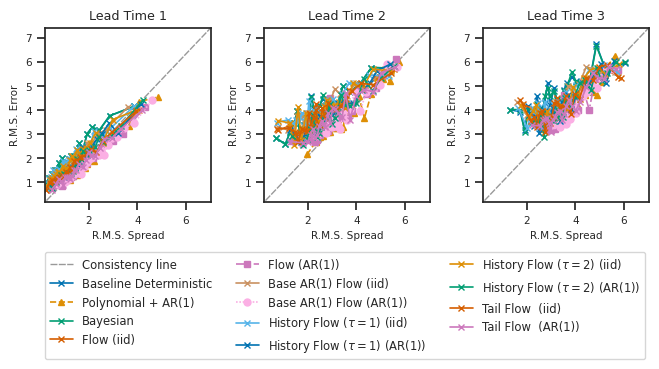

In [52]:
set_model_order(REDUCED_MODEL_ORDER)
which = "mix"  # full or mix
M = 400 if which == "full" else 20  # n_ens * n_models for full, n_ens for mix
f_dir = paper_f_dir_f if which == "full" else paper_f_dir_m

df = df_spread_error_f if "full" else df_spread_error_m

lead_times = [1, 2, 3]
fig = plot_spread_error_all_models(
    df,
    lead_time=lead_times,
    M=M,
    figsize=(TEXT_WIDTH, 5),
    legend_cols=3,
    bbox_to_anchor=(0.07, 0.0),
    legend_loc="lower left",
    models_to_plot=REDUCED_MODEL_ORDER,
    speical_markers_and_lines=True,  # special markers and line styles for selected models
)
plt.show()
which_str = "_full" if which == "full" else "_mix"

lt_str = "_lead_times_" + "-".join(str(lt) for lt in lead_times)

fig.savefig(
    f_dir / f"spread_error{which_str}{lt_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
# reset model
set_model_order(MODEL_ORDER_DEFAULT)

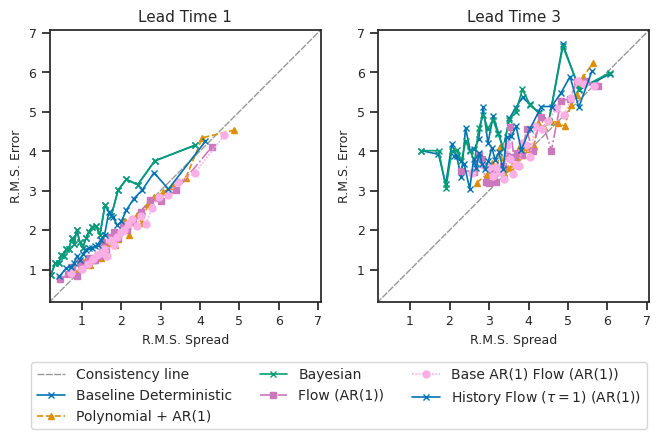

In [53]:
set_model_order(REDUCED_MODEL_ORDER_SELECTED)
which = "full"  # full or mix
f_dir = paper_f_dir_f if which == "full" else paper_f_dir_m
M = 400 if which == "full" else 20  # n_ens * n_models for full, n_ens for mix

df = df_spread_error_f if "full" else df_spread_error_m

lead_times = [1, 3]
fig = plot_spread_error_all_models(
    df,
    lead_time=lead_times,
    M=M,
    figsize=(TEXT_WIDTH, 5),
    subplot_cols=2,
    legend_cols=3,
    models_to_plot=REDUCED_MODEL_ORDER_SELECTED,
    which_base_width="column",
    bbox_to_anchor=(0.98, -0.04),
    legend_loc="lower right",
    speical_markers_and_lines=True,  # special markers and line styles for selected models
)
plt.show()
which_str = "_full" if which == "full" else "_mix"

lt_str = "_lead_times_" + "-".join(str(lt) for lt in lead_times)

fig.savefig(
    f_dir / f"spread_error{which_str}{lt_str}_selected.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
# reset model
set_model_order(MODEL_ORDER_DEFAULT)

#### Spread-error as grid

In [54]:
def plot_spread_error_grid(
    df,
    lead_time,
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(15, 10),
    M=400,  # n_ens * n_models for full, n_ens for mix
    ncols=3,
    bbox_to_anchor=(1.01, 0.5),
    legend_loc="upper left",
    which_base_width="text",
    title_line_breaks=False,
):
    """
    Spread-error diagram at one lead time.
    One model per panel.
    """
    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "figure.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )

    g = df.copy()
    if g.empty:
        raise ValueError("No data provided")

    g = g[g["lead_time"].astype(int) == int(lead_time)].copy()
    if g.empty:
        raise ValueError("No rows left after lead_time filtering")

    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    if not keys:
        raise ValueError("No matching models_to_plot found in MODEL_ORDER")

    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
        squeeze=False,
    )
    axes = np.atleast_2d(axes)

    slope = np.sqrt((M + 1.0) / (M - 1.0)) if M is not None else 1.0
    diag_style = (0, (5, 1))
    lw = 1.2

    # -- Optional fixed limits/ticks for comparison across lead times
    # dynamically compute limits
    x_max = max(np.nanmax(v) for v in g["rms_spread"])
    y_max = max(np.nanmax(v) for v in g["rms_error"])
    x_min = min(np.nanmin(v) for v in g["rms_spread"])
    y_min = min(np.nanmin(v) for v in g["rms_error"])

    # Fixed limits and ticks for better comparison across lead times; adjust as needed
    fixed_x_ticks = list(range(1, 8))
    fixed_y_ticks = list(range(1, 8))
    x_min = min(x_min, min(fixed_x_ticks))
    x_max = max(x_max, max(fixed_x_ticks))
    y_min = min(y_min, min(fixed_y_ticks))
    y_max = max(y_max, max(fixed_y_ticks))

    max_lim = max(x_max, y_max) * 1.05 if max(x_max, y_max) > 0 else 1.0
    min_lim = min(x_min, y_min) * 0.9 if min(x_min, y_min) > 0 else 0.0
    # ---

    for idx, order_key in enumerate(keys):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        color = COLOR_MAP.get(order_key, None)

        ax.plot(
            [0, max_lim],
            [0, slope * max_lim],
            linestyle=diag_style,
            linewidth=1.0,
            color="0.6",
            label="Consistency line",
        )

        try:
            gg = select_spread_error_from_df(g, model, noise, ar_order, delta_t)
        except (KeyError, ValueError):
            gg = None

        if gg is not None and not gg.empty:
            x = gg["rms_spread"].iloc[0]
            y = gg["rms_error"].iloc[0]

            ax.plot(
                x,
                y,
                color=color,
                lw=lw,
                marker="x",
                markersize=5,
            )

        title = parse_label(
            model, noise, ar_order, delta_t, line_breaks=title_line_breaks
        )
        ax.set_title(title)

        ax.set_xlim(min_lim, max_lim)
        ax.set_ylim(min_lim, max_lim * slope)
        ax.set_aspect("equal", adjustable="box")
        # -- Fixed xticks and yticks for better comparison across lead times; adjust as needed
        ax.set_xticks(fixed_x_ticks)
        ax.set_yticks(fixed_y_ticks)
        # -- Dynamic ticks based on max_lim
        # ax.set_xticks(list(range(1, int(max_lim) + 1, max(1, int(max_lim) // 4))))
        # ax.set_yticks(list(range(1, int(max_lim) + 1, max(1, int(max_lim) // 4))))
        ax.tick_params(axis="both", bottom=True, left=True, length=3)

        if r == nrows - 1:
            ax.set_xlabel("R.M.S. Spread")
        if c == 0:
            ax.set_ylabel("R.M.S. Error")

    # hide unused subplots

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    fig.suptitle(f"Lead Time {lead_time}", y=1.01)

    fig.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="0.6",
                lw=1.0,
                ls=diag_style,
                label="Consistency line",
            )
        ],
        loc=legend_loc,
        bbox_to_anchor=bbox_to_anchor,
        frameon=True,
    )

    return fig

#### Paper ready

In [55]:
paper_f_dir_f = paper_figures_base_dir / "full"
paper_f_dir_f.mkdir(parents=True, exist_ok=True)
print(f"Saving full to figures dir: {Path(*paper_f_dir_f.parts[-4:])}")

paper_f_dir_m = paper_figures_base_dir / "mix"
paper_f_dir_m.mkdir(parents=True, exist_ok=True)
print(f"Saving mix to figures dir: {Path(*paper_f_dir_m.parts[-4:])}")

Saving full to figures dir: paper/figures/ensemble_evaluation/full
Saving mix to figures dir: paper/figures/ensemble_evaluation/mix


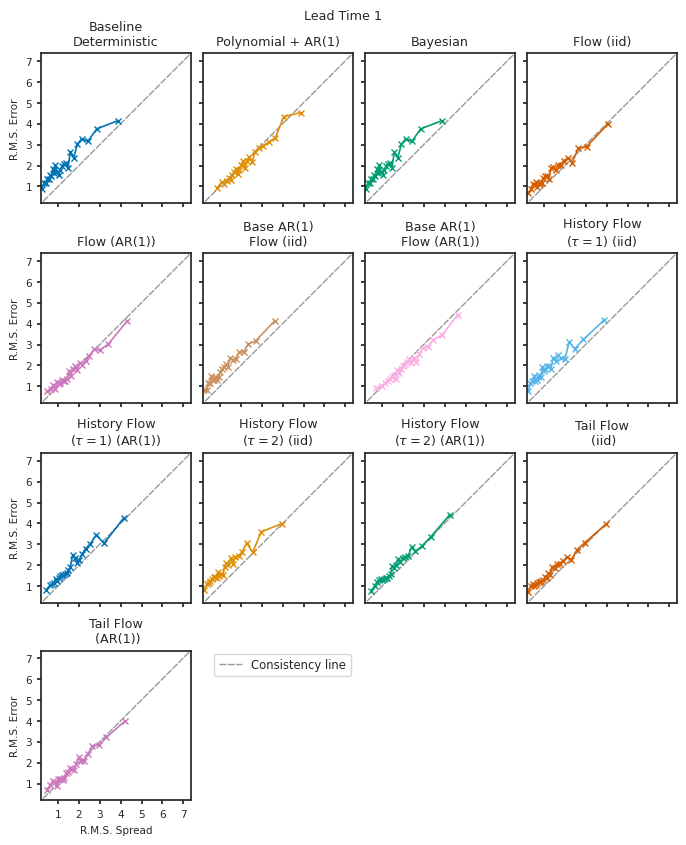

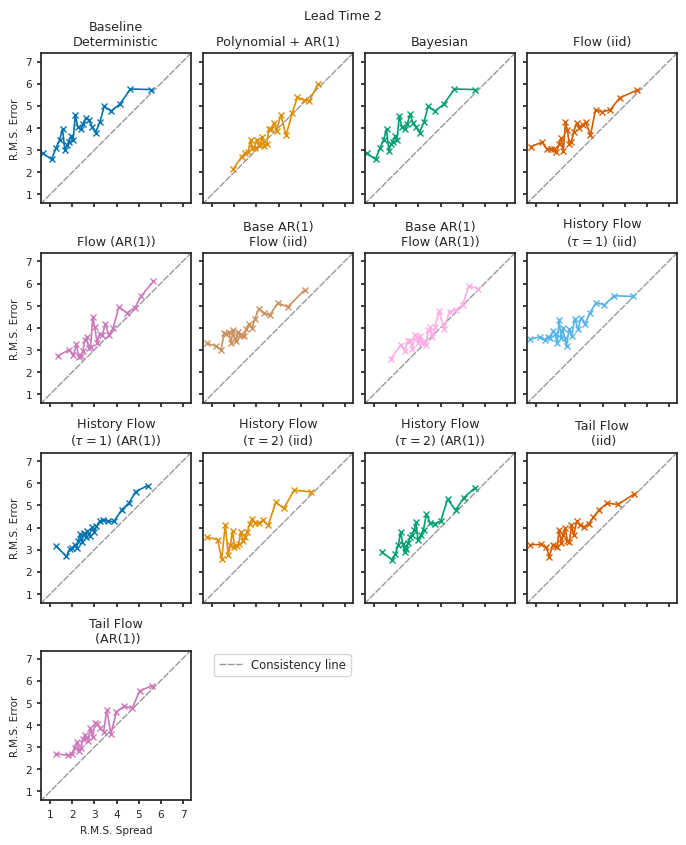

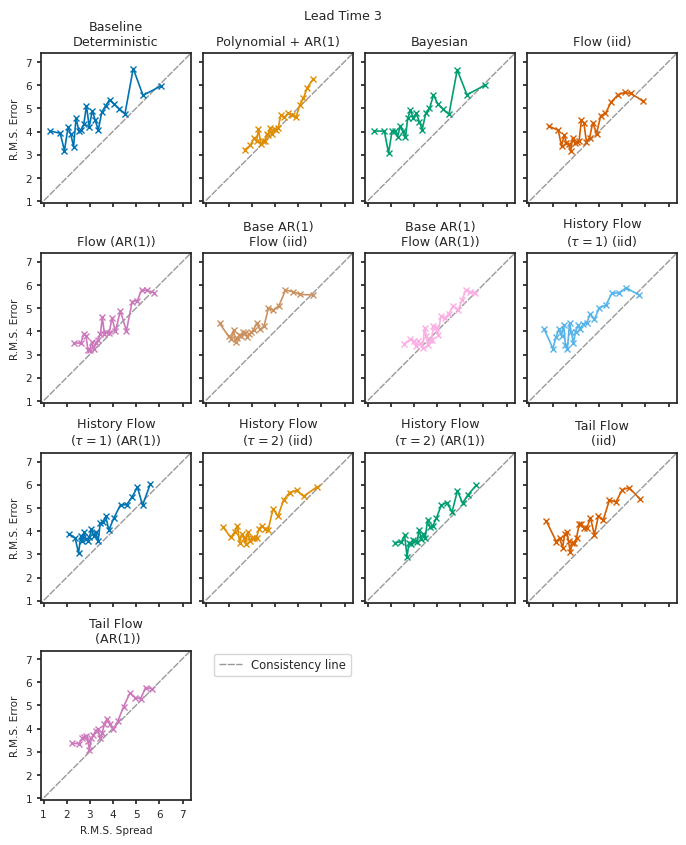

In [56]:
set_model_order(REDUCED_MODEL_ORDER)
which = "full"  # full or mix
f_dir = paper_f_dir_f if which == "full" else paper_f_dir_m
M = 400 if which == "full" else 20  # n_ens * n_models for full, n_ens for mix

df = df_spread_error_f if "full" else df_spread_error_m

for lead_time in [1, 2, 3]:
    fig = plot_spread_error_grid(
        df,
        M=M,
        lead_time=lead_time,
        ncols=4,
        figsize=(TEXT_WIDTH, 8.2),
        bbox_to_anchor=(0.3, 0.19),
        legend_loc="lower left",
        models_to_plot=REDUCED_MODEL_ORDER,
        which_base_width="text",
        title_line_breaks=True,
    )
    plt.show()
    which_str = "_full" if which == "full" else "_mix"

    lt_str = "_lead_time_" + str(lead_time)

    fig.savefig(
        f_dir / f"spread_error_grid{which_str}{lt_str}.pdf",
        bbox_inches="tight",
        pad_inches=0.01,
        format="pdf",
    )
# reset model
set_model_order(MODEL_ORDER_DEFAULT)